# Prediction Error vs. Video Duration
How well do human behavioral reports (final frame) and model predictions (DINOv2, V-JEPA2) track each other's category-report rates, across video duration? Compares three input conditions per model: **full clip**, **last frame only**, and **shuffled frames**.

In [1]:
import sys
sys.path.append('/home/aicha/Ego4D')

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from sklearn.metrics import mean_squared_error

import data_loaders, reliability, utils
importlib.reload(data_loaders)
importlib.reload(reliability)
importlib.reload(utils)

from data_loaders import load_humanReportRates, load_humanTrialData_frames
from reliability import load_reliability_durations
from utils import compute_meanHR

## Config

In [6]:
categories = ['Cup', 'Knife', 'Chair', 'Person', 'Car', 'Bike',
              'Dog', 'Cat', 'Table', 'Book', 'Plant', 'Bed']

duration_bins = [0.1, 0.5, 1, 1.5, 2, 3, 4, 6, 8, 15]
sample_size   = 32   # noise-floor bootstrap sample size
repetitions   = 100  # bootstrap resamples

MODEL_DIR            = '/braintree/home/aicha/Ego4D/model_eval/result_csvs/'
LAST_FRAME_DINO_DIR  = '/braintree/home/aicha/part_2/dino_v2_h1_exp3/'
LAST_FRAME_VJEPA_DIR = '/braintree/home/aicha/part_2/vjepa2_h1_exp4/'
SHUFFLED_DINO_DIR    = '/braintree/home/aicha/part_2/dino_v2_v2/'
SHUFFLED_VJEPA_DIR   = '/braintree/home/aicha/part_2/vjepa2_h1_shuffled/'

# One row per model variant. `kind` groups by architecture (for color), `view`
# groups by input condition (for linestyle). `col` (prediction column name in
# test_df) is filled in once predictions are loaded below.
model_configs = [
    {'name': 'DINOv2', 'kind': 'Frame based model', 'view': 'full_clip',
     'csv': MODEL_DIR + 'dino_v2-dino_v2_60frames_15epochs_lr_0.001_wd_0.8_baseline_fps_4_preds_60Frames_AttentionalPooling.csv'},
    {'name': 'V-JEPA2', 'kind': 'Video based model', 'view': 'full_clip',
     'csv': MODEL_DIR + 'vjepa2_60frames_15epochs_lr_0.001_wd_0.01_baseline_preds_60Frames_AttentionalPooling.csv'},
    {'name': 'DINOv2-LastFrame', 'kind': 'Frame based model', 'view': 'last_frame',
     'csv': LAST_FRAME_DINO_DIR + 'h1_exp3_dino_v2-dino_v2_1frames_15epochs_lr_0.001_wd_0.8_baseline_fps_4_preds_1Frames_AttentionalPooling.csv'},
    {'name': 'V-JEPA2-LastFrame', 'kind': 'Video based model', 'view': 'last_frame',
     'csv': LAST_FRAME_VJEPA_DIR + 'h1_exp4_vjepa2-vjepa2_1frames_15epochs_lr_0.001_wd_0.01_baseline_fps_4_preds_2Frames_AttentionalPooling.csv'},
    {'name': 'DINOv2-Shuffled', 'kind': 'Frame based model', 'view': 'shuffled',
     'csv': SHUFFLED_DINO_DIR + 'v2_dino_v2-dino_v2_60frames_15epochs_lr_0.001_wd_0.8_baseline_fps_4_preds_60Frames_AttentionalPooling.csv'},
    {'name': 'V-JEPA2-Shuffled', 'kind': 'Video based model', 'view': 'shuffled',
     'csv': SHUFFLED_VJEPA_DIR + 'h1_shuffled_vjepa2-vjepa2_60frames_15epochs_lr_0.001_wd_0.01_baseline_fps_4_preds_60Frames_AttentionalPooling.csv'},
]

## Load human behavioral reports
Full-clip human report rates (ground truth), binned by video duration.

In [7]:
test_df = load_humanReportRates('test')
test_df['videoDuration_bins'], _ = pd.cut(
    test_df['videoDuration (sec)'], bins=duration_bins, retbins=True
)
test_df = test_df.melt(
    id_vars=['video_type', 'File_name', 'stimulus_video_url',
             'Video_ID', 'videoDuration (sec)', 'video_number', 'videoDuration_bins', 'n_clusters'],
    value_vars=categories,
    var_name='category',
    value_name='prediction'
)
test_df['tmp'] = test_df['File_name'] + '_' + test_df['category']
print(f"{len(test_df)} (video, category) rows")

10824 (video, category) rows


### Human last-frame baseline
Human report rates from seeing only the final frame — the behavioral counterpart to the models' last-frame condition.

In [8]:
frame_df = load_humanTrialData_frames()
frame_df = frame_df.loc[frame_df['image_type'] == 'FinalFrame']

frame_agg = frame_df.groupby(
    ['File_ID', 'File_name'], as_index=False
)['final_choice'].apply(lambda x: compute_meanHR(x))
frame_agg[categories] = frame_agg['final_choice'].apply(pd.Series)
frame_agg = frame_agg.melt(
    id_vars=['File_ID', 'File_name'],
    value_vars=categories,
    var_name='category',
    value_name='prediction'
)
frame_agg['tmp'] = frame_agg['File_name'] + '_' + frame_agg['category']

test_df['frame_prediction'] = test_df['tmp'].map(
    dict(zip(frame_agg['tmp'], frame_agg['prediction']))
)
test_df = test_df.loc[test_df['frame_prediction'].notna()]
print(f"{len(test_df)} rows with a matching last-frame human report")

/braintree/home/aicha/master_thesis/data_loaders.py:50: DtypeWarning: Columns (28,30,32,34,36,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


9336 rows with a matching last-frame human report


## Load model predictions
Merge each model variant's predictions into `test_df` by (video, category).

In [9]:
for cfg in model_configs:
    preds = pd.read_csv(cfg['csv'])
    preds['tmp'] = preds['videoID'] + '_' + preds['category']
    cfg['col'] = f"{cfg['name'].lower().replace('-', '_')}_prediction"
    test_df[cfg['col']] = test_df['tmp'].map(
        dict(zip(preds['tmp'], preds['prediction']))
    ).clip(lower=0, upper=1)

# Includes the human last-frame baseline (added in the previous cell) so it's
# covered by the same bootstrap loop and plot logic as the model predictors.
pred_cols = [cfg['col'] for cfg in model_configs] + ['frame_prediction']
test_df[pred_cols].describe()

,dinov2_prediction,v_jepa2_prediction,dinov2_lastframe_prediction,v_jepa2_lastframe_prediction,dinov2_shuffled_prediction,v_jepa2_shuffled_prediction,frame_prediction
count,9336.000000,9336.000000,9336.000000,9336.000000,9336.000000,9336.000000,9336.000000
mean,0.105512,0.104463,0.104724,0.097942,0.118525,0.104892,0.092265
std,0.208767,0.205472,0.206835,0.190365,0.225628,0.204440,0.189251
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.001653,0.000000,0.001513,0.000000,0.001906,0.000000
50%,0.011503,0.010987,0.013119,0.015908,0.013892,0.012559,0.000000
75%,0.069407,0.070371,0.072686,0.070717,0.087422,0.070802,0.080000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Noise floor
Human split-half reliability (MSE), by duration bin — the error we'd expect even from a second, independent sample of human reports.

In [10]:
reliability_df = load_reliability_durations(
    N=sample_size, repetitions=repetitions,
    recompute=False, duration_bins=duration_bins
)

noise_floor_df = reliability_df.loc[
    (reliability_df['metric']      == 'MSE') &
    (reliability_df['type']        == 'prediction') &
    (reliability_df['category']    == 'all') &
    (reliability_df['Sample size'] == sample_size) &
    (reliability_df['kind'].isin([
        '(0.1, 0.5]', '(0.5, 1.0]', '(1.0, 1.5]', '(1.5, 2.0]',
        '(2.0, 3.0]', '(3.0, 4.0]', '(4.0, 6.0]', '(6.0, 8.0]', '(8.0, 15.0]'
    ]))
]
noise_floor_df.head()

,Repetition,Sample size,Reliability,metric,kind,category,type
59007,0,32.0,0.002267,MSE,"(3.0, 4.0]",all,prediction
59027,1,32.0,0.003871,MSE,"(3.0, 4.0]",all,prediction
59047,2,32.0,0.002246,MSE,"(3.0, 4.0]",all,prediction
59067,3,32.0,0.002877,MSE,"(3.0, 4.0]",all,prediction
59087,4,32.0,0.002684,MSE,"(3.0, 4.0]",all,prediction


## Bootstrap MSE by duration bin
For each predictor, resample videos with replacement (within duration bin) and compute MSE vs. human full-clip reports, `repetitions` times.

In [11]:
df_boots = []
for b in range(repetitions):
    boot = test_df.groupby('videoDuration_bins').sample(frac=1, replace=True)
    for pred in pred_cols:
        mse = boot.groupby('videoDuration_bins', as_index=False).apply(
            lambda x: mean_squared_error(x[pred], x['prediction'])
        )
        mse['b'] = b
        mse['predictor'] = pred
        df_boots.append(mse)

df_boots = pd.concat(df_boots, ignore_index=True).rename(columns={None: 'mse'})
df_boots.head()

/tmp/ipykernel_9013/3759711180.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  boot = test_df.groupby('videoDuration_bins').sample(frac=1, replace=True)
/tmp/ipykernel_9013/3759711180.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mse = boot.groupby('videoDuration_bins', as_index=False).apply(
/tmp/ipykernel_9013/3759711180.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select t

,videoDuration_bins,mse,b,predictor
0,"(0.1, 0.5]",0.003528,0,dinov2_prediction
1,"(0.5, 1.0]",0.003516,0,dinov2_prediction
2,"(1.0, 1.5]",0.002925,0,dinov2_prediction
3,"(1.5, 2.0]",0.003388,0,dinov2_prediction
4,"(2.0, 3.0]",0.003646,0,dinov2_prediction


## Plot

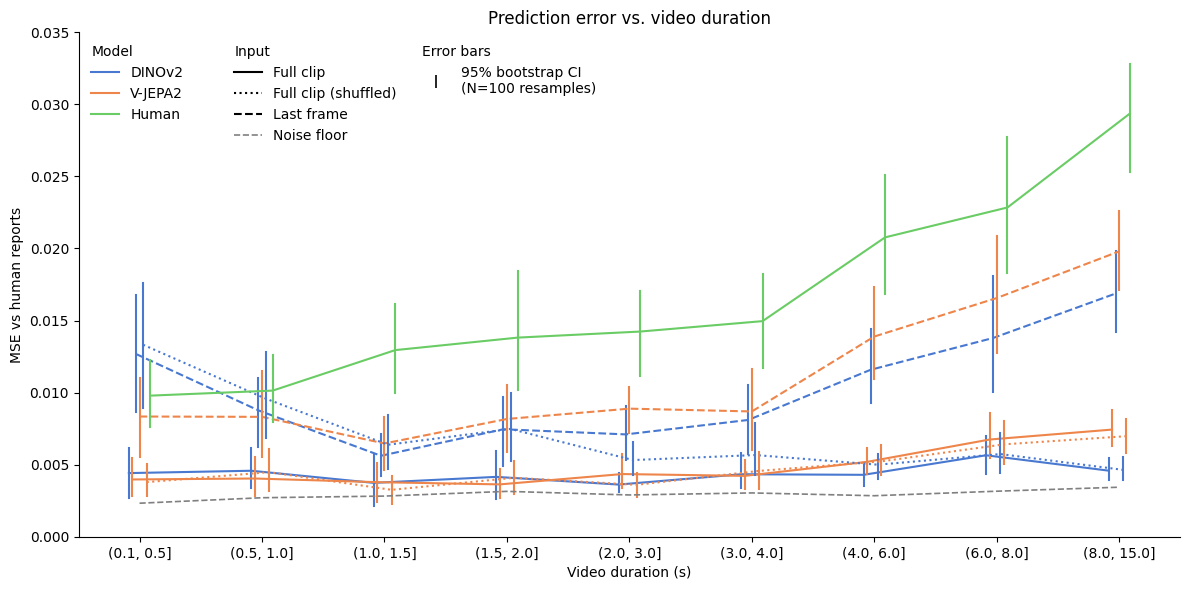

In [12]:
hue_order = pred_cols

palette = sns.color_palette('muted', 3)
model_colors = {
    'Frame based model': palette[0],  # DINOv2
    'Video based model': palette[1],  # V-JEPA2
}
colors = [model_colors[cfg['kind']] for cfg in model_configs] + [palette[2]]  # + human
noise_color = 'grey'

view_linestyles = {'full_clip': '-', 'shuffled': ':', 'last_frame': '--'}
linestyles = [view_linestyles[cfg['view']] for cfg in model_configs] + ['-']  # human: solid

g = sns.catplot(
    data=df_boots, x='videoDuration_bins', y='mse', kind='point',
    errorbar=('pi', 95), hue='predictor', hue_order=hue_order, palette=colors,
    markers='o', markersize=0, linewidth=1.5, linestyles=linestyles,
    dodge=True, legend=False, aspect=2, height=6,
)

nf_mean = noise_floor_df.groupby('kind')['Reliability'].mean().reset_index()
ax = g.axes[0][0]
ax.plot(range(len(nf_mean)), nf_mean['Reliability'].values,
        color=noise_color, linestyle='--', linewidth=1.2)

g.set(ylim=(0.00, 0.035))
g.set_xlabels('Video duration (s)')
g.set_ylabels('MSE vs human reports')
ax.set_title('Prediction error vs. video duration')

model_legend = [
    Line2D([0], [0], color=model_colors['Frame based model'], lw=1.5, label='DINOv2'),
    Line2D([0], [0], color=model_colors['Video based model'], lw=1.5, label='V-JEPA2'),
    Line2D([0], [0], color=palette[2], lw=1.5, label='Human'),
]
view_legend = [
    Line2D([0], [0], color='black', lw=1.5, linestyle='-', label='Full clip'),
    Line2D([0], [0], color='black', lw=1.5, linestyle=':', label='Full clip (shuffled)'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Last frame'),
    Line2D([0], [0], color=noise_color, lw=1.2, linestyle='--', label='Noise floor'),
]
error_bar_proxy = ax.errorbar([], [], yerr=[], fmt='none', ecolor='black',
                               elinewidth=1.2, capsize=3, label='95% bootstrap CI\n(N=100 resamples)')

l1 = ax.legend(handles=model_legend, loc='upper left', frameon=False, title='Model', alignment='left')
ax.add_artist(l1)
l2 = ax.legend(handles=view_legend, loc='upper left', bbox_to_anchor=(0.13, 1.0),
               frameon=False, title='Input', alignment='left')
ax.add_artist(l2)
ax.legend(handles=[error_bar_proxy], loc='upper left', bbox_to_anchor=(0.30, 1.0),
          frameon=False, title='Error bars', alignment='left')

plt.tight_layout()
plt.show()